# Training the XGBoost Model

In the train_xgboost.py file, 3 separate models are created, one for SL, GS, and SG. The features taken into consideration are (where X is the discipline: SL, GS, or SG):  
* YOB
* Gender
* total_race_starts
* total_finishes
* overall_finish_rate
* wins
* podiums
* top_5s
* top_10s
* X starts
* X wins
* X podiums
* X top 5s
* X top 10s
* X finish rate
* Zone avg percentile
* Provincial avg percentile
* Regional avg percentile
* National avg percentile
* International avg percentile
* X Zone avg percentile
* X Provincial avg percentile
* X Regional avg percentile
* X National avg percentile
* X International avg percentile

The target labels are SL_target, GS_target, or SG_target depending on which model is being used. The train-test split of the data is 80-20 and the data is stratified. The sample weights set-up helps balance the penalization of the model getting certain predictions wrong. For example, getting a class-0 athlete wrong matters much more to the training process than getting a class-6 athlete wrong.

The models use the XGBClassifier with a log loss evaluation metric and does multi-class classification with softprob to give the predicted probability of a data point belonging to each class. 

In [34]:
import pandas as pd
from itables import show
import matplotlib.pyplot as plt
import seaborn as sns

### GS #### 
gs_df = pd.read_parquet(
    "../data/processed/gs_train_xgboost.parquet"
)

gs_report = pd.read_parquet(
    "../data/processed/gs_classification_report.parquet"
)

gs_cm = pd.read_parquet(
    "../data/processed/gs_confusion_matrix.parquet"
)

### SLALOM #### 
sl_df = pd.read_parquet(
    "../data/processed/sl_train_xgboost.parquet"
)

sl_report = pd.read_parquet(
    "../data/processed/sl_classification_report.parquet"
)

sl_cm = pd.read_parquet(
    "../data/processed/sl_confusion_matrix.parquet"
)

### SUPER G #### 
sg_df = pd.read_parquet(
    "../data/processed/sg_train_xgboost.parquet"
)

sg_report = pd.read_parquet(
    "../data/processed/sg_classification_report.parquet"
)

sg_cm = pd.read_parquet(
    "../data/processed/sg_confusion_matrix.parquet"
)

## Visualizing the Results

Printing the report and displaying the confusion matrix for the 3 disciplines

SL Report


,precision,recall,f1-score,support
0.0,0.000000,0.000000,0.000000,4.000000
1.0,0.400000,0.250000,0.307692,8.000000
2.0,0.272727,0.375000,0.315789,24.000000
3.0,0.272727,0.250000,0.260870,24.000000
4.0,0.192308,0.208333,0.200000,24.000000
5.0,0.261905,0.392857,0.314286,56.000000
6.0,0.891089,0.808383,0.847724,334.000000
accuracy,0.662447,0.662447,0.662447,0.662447
macro avg,0.327251,0.326368,0.320909,474.000000
weighted avg,0.702947,0.662447,0.678990,474.000000


GS Report


,precision,recall,f1-score,support
0.0,0.500000,0.250000,0.333333,4.000000
1.0,0.000000,0.000000,0.000000,8.000000
2.0,0.470588,0.444444,0.457143,18.000000
3.0,0.187500,0.315789,0.235294,19.000000
4.0,0.157895,0.272727,0.200000,22.000000
5.0,0.239130,0.385965,0.295302,57.000000
6.0,0.901460,0.750760,0.819237,329.000000
accuracy,0.634573,0.634573,0.634573,0.634573
macro avg,0.350939,0.345669,0.334330,457.000000
weighted avg,0.717106,0.634573,0.666945,457.000000


SG Report


,precision,recall,f1-score,support
0.0,0.000000,0.000000,0.000000,2.000000
1.0,0.285714,0.400000,0.333333,10.000000
2.0,0.294118,0.217391,0.250000,23.000000
3.0,0.176471,0.193548,0.184615,31.000000
4.0,0.360000,0.250000,0.295082,36.000000
5.0,0.410256,0.470588,0.438356,68.000000
6.0,0.587302,0.606557,0.596774,61.000000
accuracy,0.402597,0.402597,0.402597,0.402597
macro avg,0.301980,0.305441,0.299737,231.000000
weighted avg,0.397296,0.402597,0.396713,231.000000


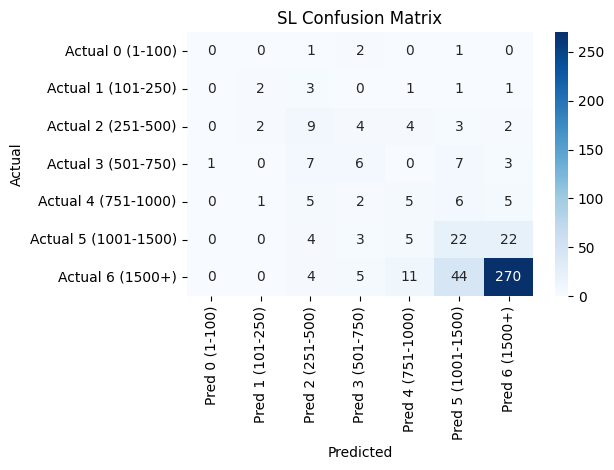

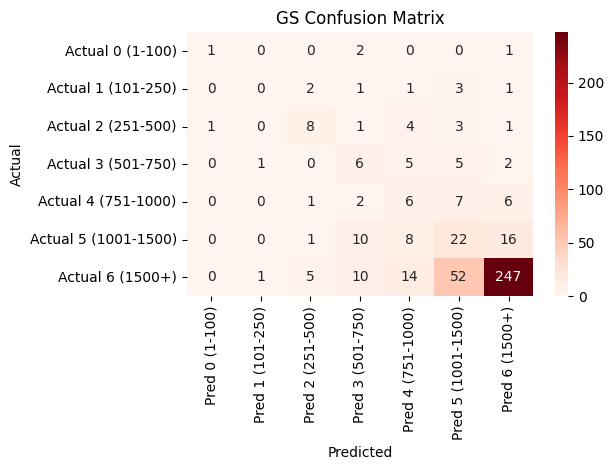

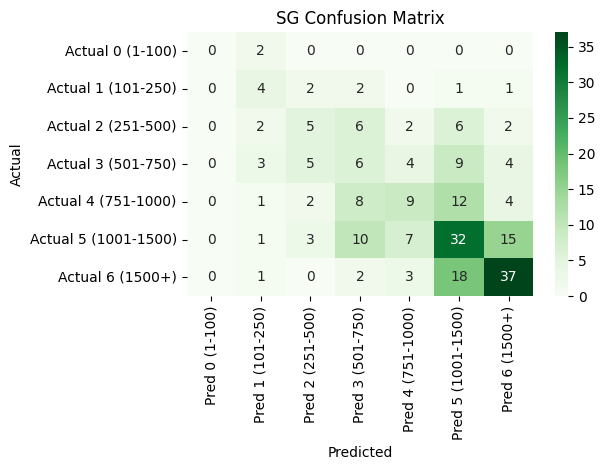

In [44]:
print("SL Report")
display(sl_report)
print("GS Report")
display(gs_report)
print("SG Report")
display(sg_report)


plt.figure()
sns.heatmap(sl_cm, annot=True, cmap='Blues', fmt='d')
plt.title('SL Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

plt.figure()
sns.heatmap(gs_cm, annot=True, cmap='Reds', fmt='d')
plt.title('GS Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

plt.figure()
sns.heatmap(sg_cm, annot=True, cmap='Greens', fmt='d')
plt.title('SG Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

### Load the models and define important features

In [45]:
# Reload models
from xgboost import XGBClassifier

sl_model = XGBClassifier()
sl_model.load_model("../models/sl_xgboost.json")
gs_model = XGBClassifier()
gs_model.load_model("../models/gs_xgboost.json")
sg_model = XGBClassifier()
sg_model.load_model("../models/sg_xgboost.json")

sl_importance = pd.Series(
    sl_model.feature_importances_,
    index=sl_model.feature_names_in_
).sort_values(ascending=False)

gs_importance = pd.Series(
    gs_model.feature_importances_,
    index=gs_model.feature_names_in_
).sort_values(ascending=False)

sg_importance = pd.Series(
    sg_model.feature_importances_,
    index=sg_model.feature_names_in_
).sort_values(ascending=False)

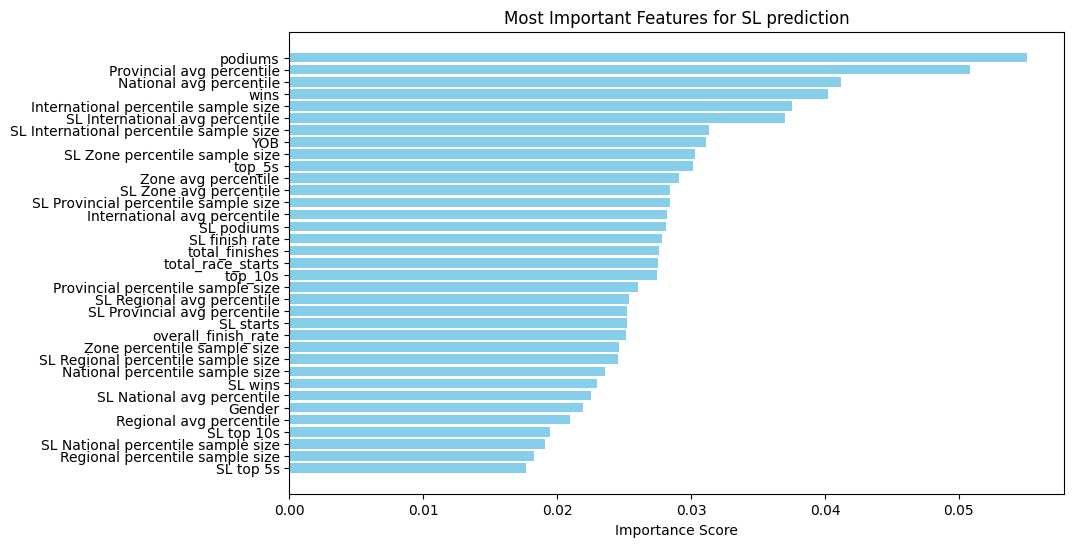

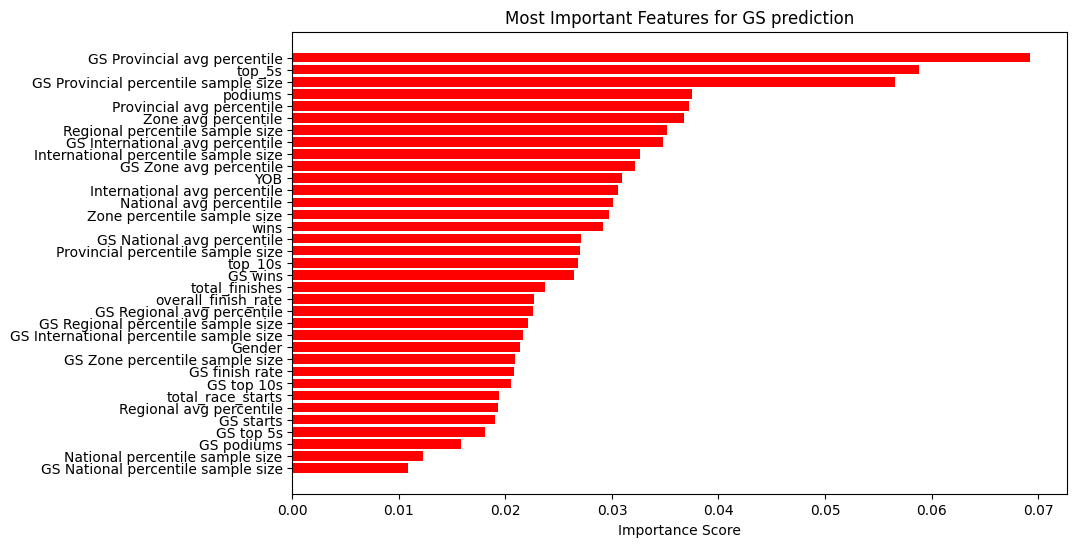

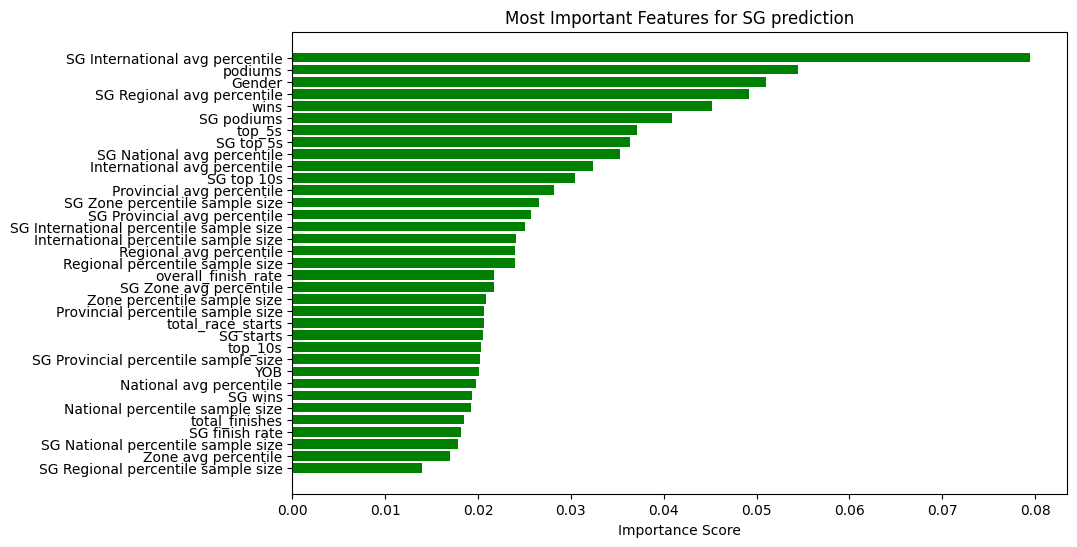

In [48]:
# visualize feature importance

### SL ###
plt.figure(figsize=(10, 6))
plt.barh(
    sl_importance.index,
    sl_importance.values,
    color="skyblue"
)
plt.gca().invert_yaxis()
plt.title("Most Important Features for SL prediction")
plt.xlabel("Importance Score")
plt.show()

### GS ###
plt.figure(figsize=(10, 6))
plt.barh(
    gs_importance.index,
    gs_importance.values,
    color="red"
)
plt.gca().invert_yaxis()
plt.title("Most Important Features for GS prediction")
plt.xlabel("Importance Score")
plt.show()

### SG ###
plt.figure(figsize=(10, 6))
plt.barh(
    sg_importance.index,
    sg_importance.values,
    color="green"
)
plt.gca().invert_yaxis()
plt.title("Most Important Features for SG prediction")
plt.xlabel("Importance Score")
plt.show()
